In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import fsolve
from functools import partial
from matplotlib.lines import Line2D 
from pathlib import Path
import math

from glob import glob
from votekit.cvr_loaders import load_scottish
from votekit.utils import first_place_votes
from votekit.elections import STV, Borda

SCOT_ELEX_PATH = "/Users/cdonnay/Documents/GitHub/MGGG/scot-elex"
# SCOT_ELEX_PATH = "/Users/cdonnay/PycharmProjects/scot-elex"

b_bloc_parties = ["Scottish National Party (SNP)", "Green (Gr)"]
b_bloc_label = "SNP and Green"
bloc_order = "AB"
stv_color = "#1560BD"
borda_color = "#FB607F"

# Compute C vs S

In [23]:
all_files = glob(f"{SCOT_ELEX_PATH}/*_cands/*.csv")
no_b_bloc_parties = 0

data_stv = {1:[], 2:[], 3:[], 4:[], 5:[]}
data_borda = {1:[], 2:[], 3:[], 4:[], 5:[]}


for file_name in all_files:
    profile, num_seats, cand_list, cand_to_party, ward_name = load_scottish(file_name)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
                else "A" for c in cand_list}

    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                    "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}

    

    fpv_dict = first_place_votes(profile)

    total_fpv = sum(fpv_dict.values())
    fpv_b_bloc = sum([v for c,v in fpv_dict.items() if cand_to_bloc[c] == "B"])
    fpv_b_share = fpv_b_bloc/total_fpv

    if bloc_to_cand_num["B"] < math.floor(fpv_b_share*num_seats) or bloc_to_cand_num["B"] == 0:
        continue 


    stv_election  = STV(profile, m = num_seats)
    stv_winners= [c for s in stv_election.get_elected() for c in s]
    stv_num_B_winners = len([c for c in stv_winners if cand_to_bloc[c] == "B"])
    stv_b_seat_share = stv_num_B_winners/num_seats
    data_stv[num_seats].append((fpv_b_share, stv_b_seat_share))

    borda_election  = Borda(profile, m = num_seats, tiebreak="first_place")
    borda_winners= [c for s in borda_election.get_elected() for c in s]
    borda_num_B_winners = len([c for c in borda_winners if cand_to_bloc[c] == "B"])
    borda_b_seat_share = borda_num_B_winners/num_seats
    data_borda[num_seats].append((fpv_b_share, borda_b_seat_share))


# print(f"This many elections do not have either B bloc party: {no_b_bloc_parties}\n")
stv_avg_sc = {num_seats: sum(y-x for (x,y) in seat_shares)/len(seat_shares) for num_seats, seat_shares in data_stv.items()}
stv_avg_abs_sc = {num_seats: sum(abs(y-x) for (x,y) in seat_shares)/len(seat_shares) for num_seats, seat_shares in data_stv.items()}
# print(f"STV Average S-C {stv_avg_sc:.2f}")
# print(f"STV Average |S-C| {stv_avg_abs_sc:.2f}")

borda_avg_sc = {num_seats: sum(y-x for (x,y) in seat_shares)/len(seat_shares) for num_seats, seat_shares in data_borda.items()}
borda_avg_abs_sc = {num_seats: sum(abs(y-x) for (x,y) in seat_shares)/len(seat_shares) for num_seats, seat_shares in data_borda.items()}
# print(f"borda Average S-C {borda_avg_sc:.2f}")
# print(f"borda Average |S-C| {borda_avg_abs_sc:.2f}")


# Plot C vs S


## STV

In [ ]:
fig, ax = plt.subplots(figsize=(14,14))
prop_line = np.linspace(-.1,1.1, 100)
ax.plot(prop_line, prop_line, label= "Proportionality", color="gray", ls= "dashed")
ax.set_ylabel(f'Share of Elected {b_bloc_label} Candidates')
ax.set_xlabel(f'Combined Support for {b_bloc_label} via FPV')  
ax.scatter([x for x,y in data_stv], [y for x,y in data_stv],color =stv_color , label = "STV")


plt.ylim(-.1, 1.1)
plt.xlim(-.1, 1.1)
plt.suptitle(f"Combined Support vs. STV Results\nScottish Elections\nSTV Average S-C {stv_avg_sc:.2f}\nSTV Average |S-C| {stv_avg_abs_sc:.2f}")
plt.legend()
plt.tight_layout()
# path_name = f"/cluster/tufts/mggg/cdonna01/PRVTP_feb_25_submission/deg_of_prop/figures/{N_SEATS}_seats/{STAT}_combined_support/all_models/{election_type}"
path_name = f"/Users/cdonnay/Documents/GitHub/MGGG/PRVTP/Disprop/deg_of_prop/figures"
file_name = f"PAPER_scottish_disprop_combined_support_fpv_stv.png"
path = Path(path_name)

plt.savefig(f"{path_name}/{file_name}", dpi=300)


## Borda

In [ ]:
fig, ax = plt.subplots(figsize=(14,14))
prop_line = np.linspace(-.1,1.1, 100)
ax.plot(prop_line, prop_line, label= "Proportionality", color="gray", ls= "dashed")
ax.set_ylabel(f'Share of Elected {b_bloc_label} Candidates')
ax.set_xlabel(f'Combined Support for {b_bloc_label} via FPV')  
ax.scatter([x for x,y in data_borda], [y for x,y in data_borda],color =borda_color , label = "Borda")


plt.ylim(-.1, 1.1)
plt.xlim(-.1, 1.1)
plt.suptitle(f"Combined support vs. Borda results\nScottish Elections\nBorda Average S-C {borda_avg_sc:.2f}\nBorda Average |S-C| {borda_avg_abs_sc:.2f}")
plt.legend()
plt.tight_layout()
# path_name = f"/cluster/tufts/mggg/cdonna01/PRVTP_feb_25_submission/deg_of_prop/figures/{N_SEATS}_seats/{STAT}_combined_support/all_models/{election_type}"
#path_name = f"/Users/cdonnay/Documents/GitHub/MGGG/PRVTP/Disprop/deg_of_prop/figures"
path_name = f"/Users/cdonnay/PycharmProjects/PRVTP/Disprop/deg_of_prop/figures"

file_name = f"PAPER_scottish_disprop_combined_support_fpv_borda.png"
path = Path(path_name)

plt.savefig(f"{path_name}/{file_name}", dpi=300)


# Both


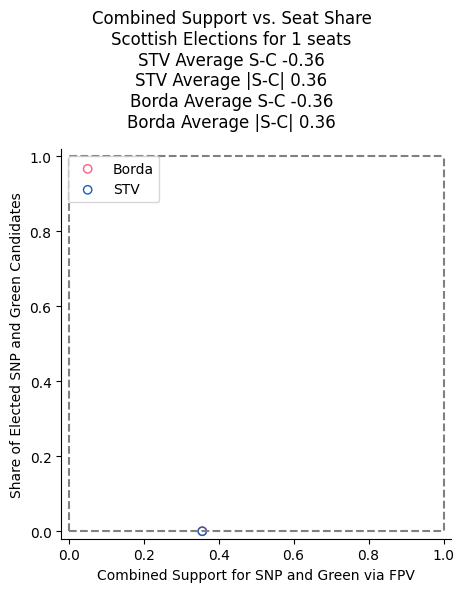

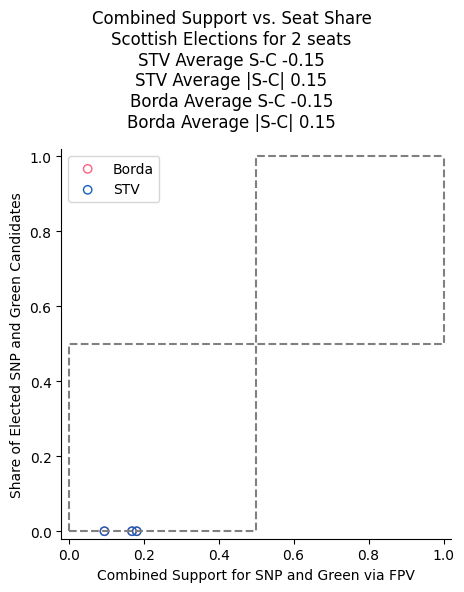

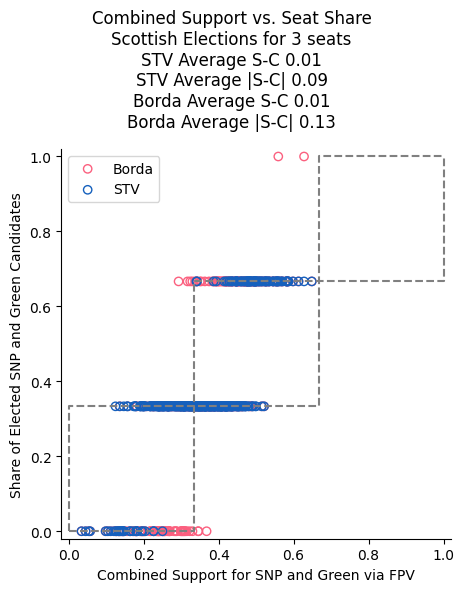

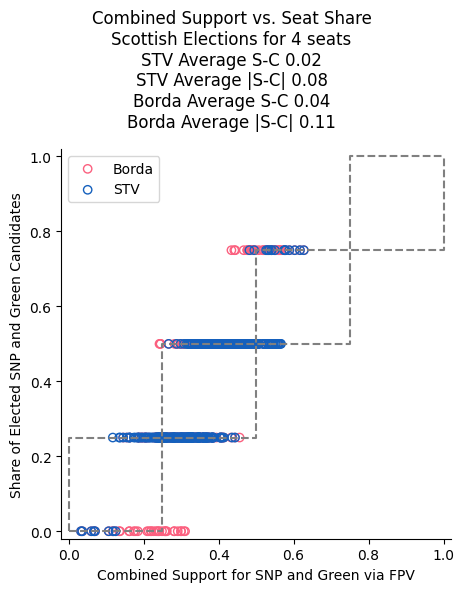

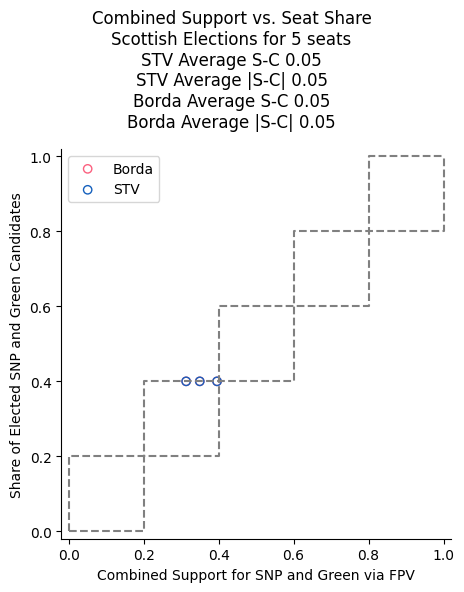

In [33]:
for num_seats in data_stv.keys():
    fig, ax = plt.subplots(figsize=(6,6))
    ax.step(
        np.linspace(0,1,num_seats+1),
        np.arange(0,1.1, 1/num_seats),
        linestyle = 'dashed',
        c='gray',
        where='pre'
    )
    ax.step(
        np.linspace(0,1,num_seats+1),
        np.arange(0,1.1, 1/num_seats),
        linestyle = 'dashed',
        c='gray',
        where='post'
    )
    ax.set_ylabel(f'Share of Elected {b_bloc_label} Candidates')
    ax.set_xlabel(f'Combined Support for {b_bloc_label} via FPV')  
    ax.scatter([x for x,y in data_borda[num_seats]], [y for x,y in data_borda[num_seats]],color =borda_color , label = "Borda", 
                            facecolors="none", 
                            #alpha=0.3,
                            #marker = "s",
                            )
    ax.scatter([x for x,y in data_stv[num_seats]], [y for x,y in data_stv[num_seats]],color =stv_color , label = "STV", 
                            facecolors="none", 
                            #alpha=0.3,
                            #marker = "^",
                            )
    ax.set_aspect("equal")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


    plt.ylim(-.02, 1.02)
    plt.xlim(-.02, 1.02)
    plt.suptitle(f"Combined Support vs. Seat Share\nScottish Elections for {num_seats} seats\nSTV Average S-C {stv_avg_sc[num_seats]:.2f}\nSTV Average |S-C| {stv_avg_abs_sc[num_seats]:.2f}\nBorda Average S-C {borda_avg_sc[num_seats]:.2f}\nBorda Average |S-C| {borda_avg_abs_sc[num_seats]:.2f}")
    plt.legend(loc = "upper left")
    plt.tight_layout()
    # path_name = f"/cluster/tufts/mggg/cdonna01/PRVTP_feb_25_submission/deg_of_prop/figures/{N_SEATS}_seats/{STAT}_combined_support/all_models/{election_type}"
    path_name = f"/Users/cdonnay/Documents/GitHub/MGGG/PRVTP/Disprop/deg_of_prop/figures"
    file_name = f"PAPER_scottish_disprop_combined_support_fpv_stv_and_borda_num_seats_{num_seats}.png"
    path = Path(path_name)


    plt.savefig(f"{path_name}/{file_name}", dpi=300)

